In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb 

In [3]:
import os
os.getcwd()

'/Users/zakariaabdullahi/Documents/crypto-dashboard-DE25-UX25/eda'

In [4]:
df = pd.read_csv("../data/interim/master_cleaned.csv")
df["date"] = pd.to_datetime(df["date"])

 ## EDA 1 
 - Volitilaty: Mesauring the how the prise sways daily.
High Volitilaty = High Risk

In [15]:
# EDA 1
# Standard Deviation of daily returns as a measure of thee volatility
vol = (
    df.groupby("coin_id")["daily_return_pct"]
    .std()
    .reset_index()
    .sort_values("daily_return_pct", ascending=False)
)
vol.index = vol.index + 1

vol



,coin_id,daily_return_pct
2,dogwifcoin,6.726459
3,floki,5.820928
4,official-trump,5.326817
1,bitcoin,2.308453


## Insight from the performance on the Chart.

As we can see the Meme coins rise faster in the short term, but then they struggle to hold that price.
But on the other hand Bitcoin shows better development in the long term.

Text(2025-12-26 00:00:00, 147.39589740008915, 'Bitcoin holds value better over time')

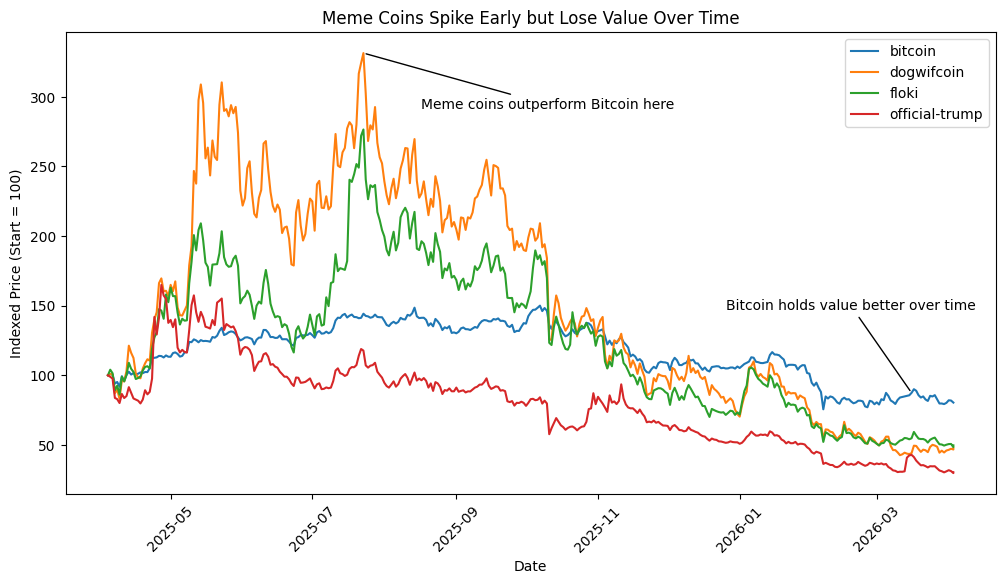

In [22]:
plt.figure(figsize=(12,6))

# Plot lines
for coin in df["coin_id"].unique():
    coin_df = df[df["coin_id"] == coin]
    plt.plot(coin_df["date"], coin_df["price_index"], label=coin)

plt.title("Meme Coins Spike Early but Lose Value Over Time")
plt.xlabel("Date")
plt.ylabel("Indexed Price (Start = 100)")
plt.legend()
plt.xticks(rotation=45)

# creating a subset of the data to find the peak of the meme coins
meme_coins = df[df["coin_id"] != "bitcoin"]
peak_idx = meme_coins["price_index"].idxmax()
peak_row = meme_coins.loc[peak_idx]

# anotation for the story telling on the peak of the meme coins performance
plt.annotate(
    "Meme coins outperform Bitcoin here",
    xy=(peak_row["date"], peak_row["price_index"]),
    xytext=(peak_row["date"] + pd.Timedelta(days=25), peak_row["price_index"] - 40),
    arrowprops=dict(arrowstyle="-"),
    fontsize=10
)

# Anotation to show that bitcoin has had a better develpment over time and is more stable. 
plt.annotate(
    "Bitcoin holds value better over time",
    xy=(end_point["date"], end_point["price_index"]),
    xytext=(end_point["date"] - pd.Timedelta(days=80), end_point["price_index"] + 60),
    arrowprops=dict(arrowstyle="-"),
    fontsize=10
)

## EDA 2 
### Average return 

- This EDA shows the average daily return on all 3 meme coins and also for Bitcoin. We can see that the meme coins may generate a highrt return from a daily perspectiv, but they also come with fastly more instabillity.
 


In [14]:
avg_return = (
    df.groupby("coin_id")["daily_return_pct"]
    .mean()
    .reset_index()
    .sort_values("daily_return_pct", ascending=False)
    .reset_index(drop=True)
)
avg_return.index = avg_return.index + 1
avg_return


,coin_id,daily_return_pct
1,dogwifcoin,0.020092
2,floki,-0.024676
3,bitcoin,-0.033072
4,official-trump,-0.191905


## EDA 3
### Maximum Drawdown

This EDA lets us look and get more insights into how much each coin has dropped down from its peak (largest loss).

This further more indicates the instability and shows us the other side of the "coin"






In [ ]:
# EDA 3 
df = df.sort_values(["coin_id", "date"]).copy()

df["cum_max"] = df.groupby("coin_id")["price"].cummax() 
df["drawdown"] = (df["price"] - df["cum_max"]) / df["cum_max"]

drawdown_smry = (
    df.groupby("coin_id")["drawdown"]
    .min()
    .reset_index()
    .sort_values("drawdown", ascending=True)
)
drawdown_smry.index = drawdown_smry.index + 1
drawdown_smry

,coin_id,drawdown
2,dogwifcoin,-0.871398
3,floki,-0.824865
4,official-trump,-0.819478
1,bitcoin,-0.496258


## Here we explore the insights on the the drawdown